In [1]:
import inspect
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from helper_functions import *

## Original V2_01_Easy Dataset with NO Modifications @6Hz

In [74]:
base_dir = '/home/shiva/Datasets/V2_01_easy/V2_01_easy/Kimera_VIO_Output'
experiment_dir = 'Baseline'

In [75]:
folders = next(os.walk(f'{base_dir}/{experiment_dir}'))[1]

In [78]:
folders

['4Hz_Frame', '6Hz_Frame']

In [77]:
del folders[0]
del folders[1]

In [79]:
dfs = []
execution_index = 1

for index, execution_folder_name in enumerate(folders):
    df = pd.read_csv(f'{base_dir}/{experiment_dir}/{execution_folder_name}/{execution_index}/traj_vio.csv')
    df['Execution'] = execution_folder_name
    df.rename(columns={'#timestamp': 'timestamp'}, inplace=True)
    dfs.append(df)

In [80]:
gt_df = pd.read_csv(f'{base_dir}/{experiment_dir}/{execution_folder_name}/{execution_index}/traj_gt.csv')
gt_df['Execution'] = 'GT'
gt_df.rename(columns={'#timestamp': 'timestamp'}, inplace=True)
dfs.append(gt_df)

In [81]:
gt_df.shape

(22401, 18)

In [82]:
all_executions = pd.concat(dfs)

In [83]:
all_executions.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 23483 entries, 0 to 22400
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  23483 non-null  int64  
 1   x          23483 non-null  float64
 2   y          23483 non-null  float64
 3   z          23483 non-null  float64
 4   qw         23483 non-null  float64
 5   qx         23483 non-null  float64
 6   qy         23483 non-null  float64
 7   qz         23483 non-null  float64
 8   vx         23483 non-null  float64
 9   vy         23483 non-null  float64
 10  vz         23483 non-null  float64
 11  bgx        23483 non-null  float64
 12  bgy        23483 non-null  float64
 13  bgz        23483 non-null  float64
 14  bax        23483 non-null  float64
 15  bay        23483 non-null  float64
 16  baz        23483 non-null  float64
 17  Execution  23483 non-null  object 
dtypes: float64(16), int64(1), object(1)
memory usage: 3.4+ MB


In [84]:
sns.set_theme(rc={'figure.figsize':(12,6)})

[(-4.0, 4.0)]

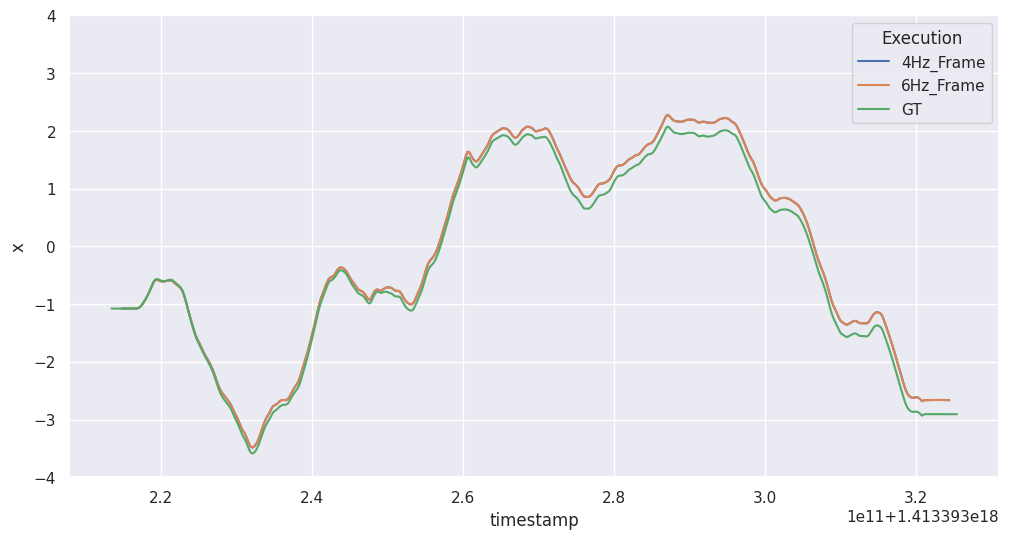

In [85]:
ax = sns.lineplot(data=all_executions, x='timestamp', y='x', hue='Execution')
ax.set(ylim=(-4, 4))

[(-4.0, 4.0)]

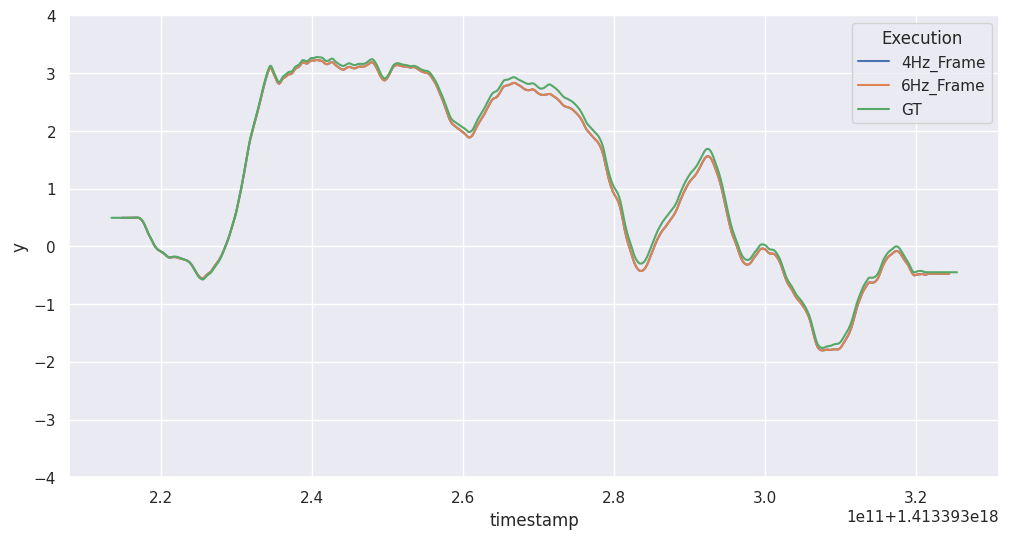

In [86]:
ax = sns.lineplot(data=all_executions, x='timestamp', y='y', hue='Execution')
ax.set(ylim=(-4, 4))

[(-4.0, 4.0)]

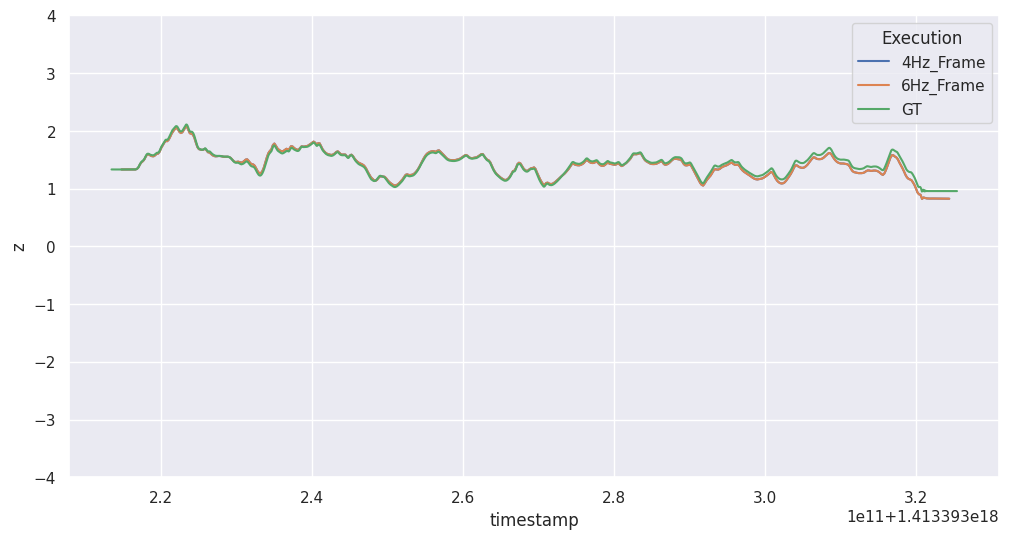

In [87]:
ax = sns.lineplot(data=all_executions, x='timestamp', y='z', hue='Execution')
ax.set(ylim=(-4, 4))

In [88]:
np.set_printoptions(precision=20)
pd.set_option('display.float_format', '{:.20f}'.format)

In [89]:
sns.set_theme(rc={'figure.figsize':(12,10)})

values = {}
for df in dfs:
    error_df = generate_error_gt_vio_pose(gt_df, df, DEBUG=False, SHOW_GRAPHS=False)
    values[df.iloc[0]['Execution']] = {'gt_x':error_df.iloc[-1]['gt_pos'][0],
                'gt_y':error_df.iloc[-1]['gt_pos'][1],
                'gt_z':error_df.iloc[-1]['gt_pos'][2],
                'vio_x': error_df.iloc[-1]['vio_pos'][0],
                'vio_y': error_df.iloc[-1]['vio_pos'][1],
                'vio_z': error_df.iloc[-1]['vio_pos'][2],
                'distance': error_df['distance'],
                'error': error_df['error']
                }

# df_comparison = pd.DataFrame(values).T
# df_comparison.reset_index(inplace=True)

# df_comparison_x_axes = pd.melt(df_comparison, id_vars='index', value_vars=['gt_x', 'vio_x'])
# df_comparison_y_axes = pd.melt(df_comparison, id_vars='index', value_vars=['gt_y', 'vio_y'])
# df_comparison_z_axes = pd.melt(df_comparison, id_vars='index', value_vars=['gt_z', 'vio_z'])

541
541
22401
exception raised, so breaking out of loop: index 0 is out of bounds for axis 0 with size 0
Empty DataFrame
Columns: [gt_index, distance]
Index: []


In [90]:
values.keys()

dict_keys(['4Hz_Frame', '6Hz_Frame', 'GT'])

In [91]:
error_distance_dfs = []

for i in values.keys():
    err_df = pd.DataFrame(data={'Distance (m)': values[i]['distance'], 'Error (m)':values[i]['error'], 'Execution':i})
    error_distance_dfs.append(err_df)

error_distance_dfs = pd.concat(error_distance_dfs)

In [92]:
res = []

for exec_no, data in error_distance_dfs.groupby('Execution'):
    print(exec_no)
    res.append(data.iloc[-1])

4Hz_Frame
6Hz_Frame
GT


In [93]:
res = pd.DataFrame(res)

In [94]:
error_distance_dfs['Execution'].unique()

array(['4Hz_Frame', '6Hz_Frame', 'GT'], dtype=object)

Text(0.5, 1.0, 'Error as Distance Increases - Baseline Experiments')

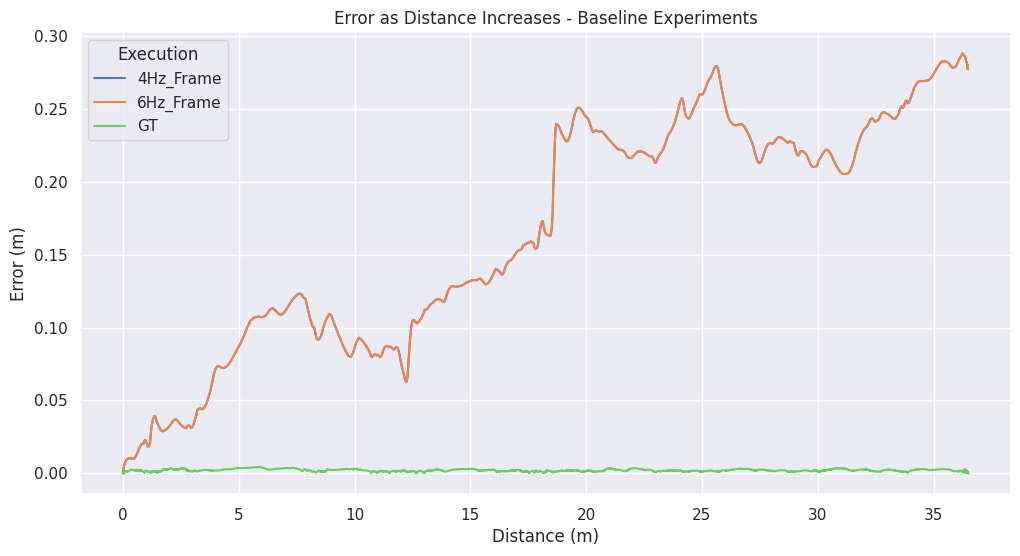

In [95]:
sns.set_theme(rc={'figure.figsize':(12, 6)})

title = 'Error as Distance Increases - Baseline Experiments'

g = sns.lineplot(data = error_distance_dfs, x='Distance (m)', y = 'Error (m)', hue='Execution', legend='full', palette='muted')
g.set_title(title)

## Results Investigation After Performing Manipulations to IMU/CAM Timestamps

In [246]:
base_dir = '/home/shiva/Datasets/V2_01_easy/V2_01_easy/Kimera_VIO_Output'
working_dir = '10_Runs_New_Kimera_Frame_Drops_6Hz_Frame'

In [247]:
execution_folder_names = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']

In [248]:
dfs = []

for index, execution_folder_name in enumerate(execution_folder_names):
    df = pd.read_csv(f'{base_dir}/{working_dir}/{execution_folder_name}/traj_vio.csv')
    df['Execution_No'] = index + 10
    df.rename(columns={'#timestamp': 'timestamp'}, inplace=True)
    dfs.append(df)

In [249]:
gt_df = pd.read_csv(f'{base_dir}/{working_dir}/{execution_folder_names[0]}/traj_gt.csv')
gt_df['Execution_No'] = 'GT'
gt_df.rename(columns={'#timestamp': 'timestamp'}, inplace=True)
dfs.append(gt_df)

In [250]:
all_executions = pd.concat(dfs)

In [251]:
all_executions

,timestamp,x,y,z,qw,qx,qy,qz,vx,vy,vz,bgx,bgy,bgz,bax,bay,baz,Execution_No
0,1413393214805760512,-1.07920100000000007689,0.49198700000000000765,1.32931700000000008188,0.60602251493983294584,-0.00643099453555270005,-0.79536432417507574311,0.00947999194480480048,0.00408700000000000035,-0.00058299999999990000,0.00054100000000000003,-0.00229500000000000016,0.02493899999999989875,0.08166700000000000348,-0.02359999999999989884,0.12104299999999990067,0.07479199999999990023,10
1,1413393215005760512,-1.07874636595799100469,0.49183002497770478278,1.32987666111134994473,0.60593349623740688781,-0.00654317982950790040,-0.79542993622515367758,0.00947495263627930011,0.00031879437376760000,0.00007898170564357709,0.00636951588502500041,-0.00232476673281839996,0.02490010694481820108,0.08169984413217740160,-0.01140109554802969972,0.12077869097456089831,0.07070892796466320129,10
2,1413393215455760384,-1.07848272586129323436,0.49188217251477311942,1.33001159118033562834,0.60546673063727984854,-0.00646145616060739975,-0.79578450880557960456,0.00948245733653309969,0.00029517730697610001,0.00283464196021600019,0.00195419439032360007,-0.00230851160797089982,0.02379001304476149881,0.08234334439497509317,0.00179205132575869998,0.12048238000171500317,0.06693933380019230495,10
3,1413393215655760384,-1.07866926462678569543,0.49197864407757141425,1.32991419228658314111,0.60506819889812546442,-0.00678515161483219959,-0.79608138577029374794,0.00965986503111910047,0.00007994243273295737,0.00303928296776089998,0.00047092035000010003,-0.00215667037882270006,0.02374199979235850147,0.08244343386877220348,0.00210385157372280007,0.12084179076518360152,0.06681769993929109752,10
4,1413393215855760384,-1.07748596958848508187,0.49242985510515058234,1.33042420535366390233,0.60323794436682320885,-0.00660759772899230033,-0.79746977896415838227,0.00961804695851120085,0.00836848781528379965,0.00363978761315550013,0.00556509955075519969,-0.00238241765448519993,0.02367818308976669950,0.08297083062463900260,-0.01544117509896049921,0.12020604566696049820,0.06789613932901389370,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22396,1413393325460760576,-2.90823600000000004329,-0.45048399999999999554,0.95496599999999998154,0.47011700000000000710,-0.48787099999999999911,-0.64120299999999996743,-0.36031900000000000039,-0.00445800000000000016,-0.00077899999999999996,0.00286799999999999989,-0.00227500000000000011,0.02488299999999999887,0.08157699999999999674,-0.01963499999999999968,0.12354199999999999904,0.07849000000000000421,GT
22397,1413393325465760512,-2.90826099999999998502,-0.45048899999999997279,0.95498099999999996879,0.47012399999999998634,-0.48787399999999997435,-0.64119499999999995943,-0.36032100000000000239,-0.00572899999999999972,-0.00088599999999999996,0.00327800000000000010,-0.00227500000000000011,0.02488299999999999887,0.08157699999999999674,-0.01963499999999999968,0.12354199999999999904,0.07849000000000000421,GT
22398,1413393325470760704,-2.90829100000000018156,-0.45049299999999997679,0.95499900000000004230,0.47014099999999997559,-0.48786499999999999311,-0.64119300000000001294,-0.36031400000000002315,-0.00596100000000000015,-0.00083600000000000005,0.00370799999999999992,-0.00227500000000000011,0.02488299999999999887,0.08157699999999999674,-0.01963499999999999968,0.12354199999999999904,0.07849000000000000421,GT
22399,1413393325475760384,-2.90831900000000009854,-0.45049699999999998079,0.95501800000000003354,0.47015800000000002035,-0.48785299999999998111,-0.64119499999999995943,-0.36030400000000001315,-0.00546899999999999990,-0.00064099999999999997,0.00404899999999999965,-0.00227500000000000011,0.02488299999999999887,0.08157699999999999674,-0.01963499999999999968,0.12354199999999999904,0.07849000000000000421,GT


<Axes: xlabel='timestamp', ylabel='x'>

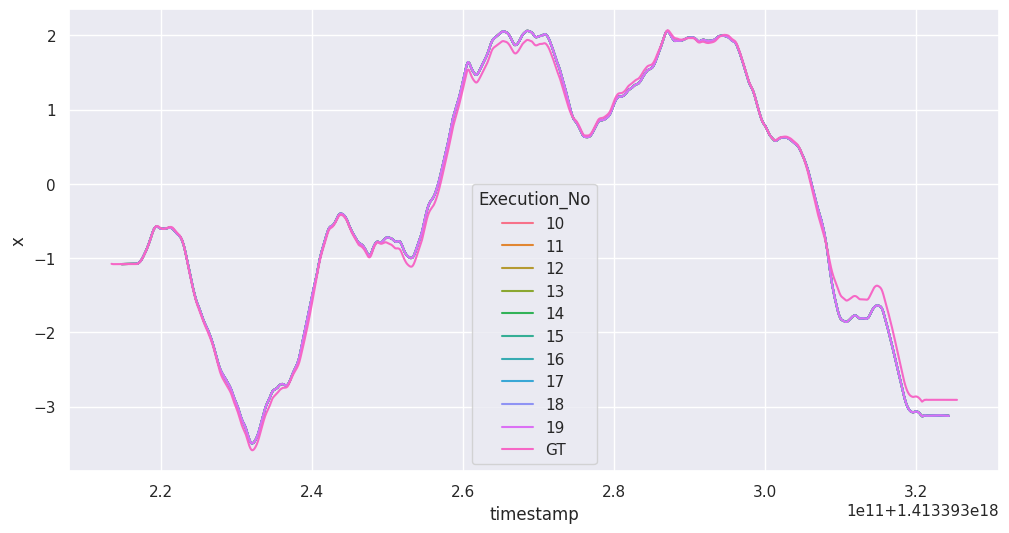

In [252]:
sns.lineplot(data=all_executions, x='timestamp', y='x', hue='Execution_No')

<Axes: xlabel='timestamp', ylabel='y'>

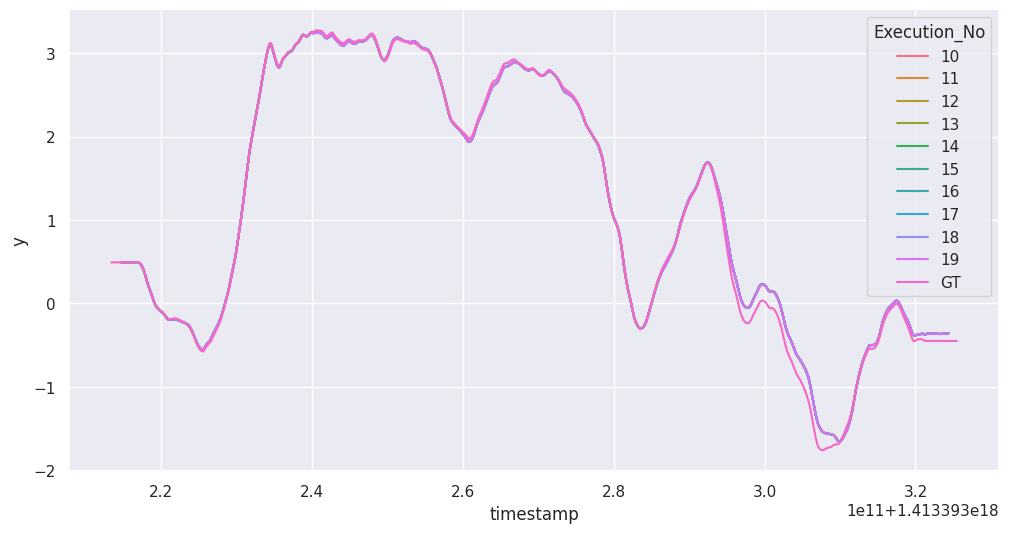

In [253]:
sns.lineplot(data=all_executions, x='timestamp', y='y', hue='Execution_No')

<Axes: xlabel='timestamp', ylabel='z'>

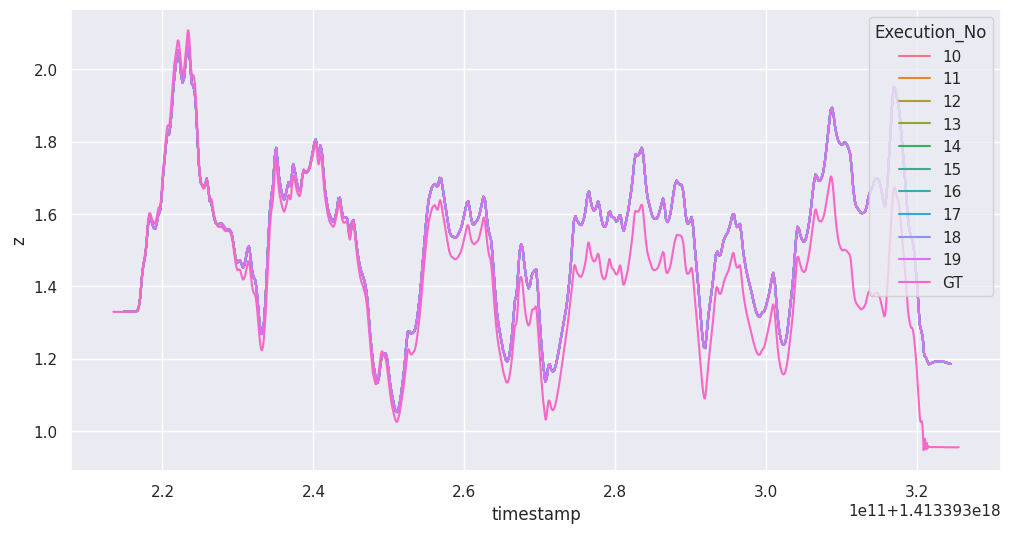

In [254]:
sns.lineplot(data=all_executions, x='timestamp', y='z', hue='Execution_No')

In [255]:
sns.set_theme(rc={'figure.figsize':(12,10)})

values = {}
for i in range(0,10):
    error_df = generate_error_gt_vio_pose(gt_df, dfs[i], DEBUG=False, SHOW_GRAPHS=False)
    values[i] = {'gt_x':error_df.iloc[-1]['gt_pos'][0],
                'gt_y':error_df.iloc[-1]['gt_pos'][1],
                'gt_z':error_df.iloc[-1]['gt_pos'][2],
                'vio_x': error_df.iloc[-1]['vio_pos'][0],
                'vio_y': error_df.iloc[-1]['vio_pos'][1],
                'vio_z': error_df.iloc[-1]['vio_pos'][2],
                'distance': error_df['distance'],
                'error': error_df['error']
                }

# df_comparison = pd.DataFrame(values).T
# df_comparison.reset_index(inplace=True)

# df_comparison_x_axes = pd.melt(df_comparison, id_vars='index', value_vars=['gt_x', 'vio_x'])
# df_comparison_y_axes = pd.melt(df_comparison, id_vars='index', value_vars=['gt_y', 'vio_y'])
# df_comparison_z_axes = pd.melt(df_comparison, id_vars='index', value_vars=['gt_z', 'vio_z'])

540
Exiting loop because next vio index i: 540
540
Exiting loop because next vio index i: 540
540
Exiting loop because next vio index i: 540
540
Exiting loop because next vio index i: 540
540
Exiting loop because next vio index i: 540
540
Exiting loop because next vio index i: 540
540
Exiting loop because next vio index i: 540
540
Exiting loop because next vio index i: 540
540
Exiting loop because next vio index i: 540
540
Exiting loop because next vio index i: 540


In [256]:
error_distance_dfs = []

for i in range(0, 10):
    df = pd.DataFrame(data={'Distance (m)': values[i]['distance'], 'Error (m)':values[i]['error'], 'Execution_No':i+1})
    error_distance_dfs.append(df)

error_distance_dfs = pd.concat(error_distance_dfs)

Text(0.5, 1.0, 'Error as Distance Increases - 6Hz w/ Frame Drops')

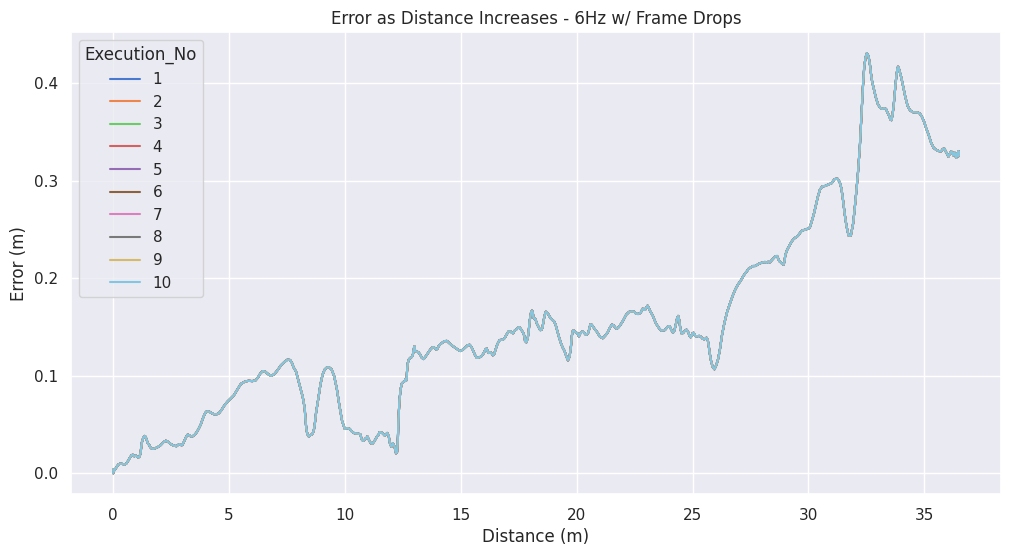

In [257]:
sns.set_theme(rc={'figure.figsize':(12, 6)})

title = 'Error as Distance Increases - 6Hz w/ Frame Drops'

g = sns.lineplot(data = error_distance_dfs, x='Distance (m)', y = 'Error (m)', hue='Execution_No', legend='full', palette='muted')
g.set_title(title)